### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.utils.data import download_file

# Type checking.
from astropy.io.fits import HDUList

### Fetch FITS image

In [2]:
INSTRUMENT: str = "INSTRUME"

# Getting real fits image.
# Famous Hubble Telescope image.
image_url: str = "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HST/product/j8pu0y010_drc.fits"

print("Downloading FITS image...")
image_file: str = download_file(remote_url=image_url, cache=True)
print("Completed download!")

Completed download!


### Open and Inspect FITS file

In [3]:
# Open and inspect fits image.
hdul: HDUList = fits.open(image_file)

header = hdul[0].header
print("------------ HEADER METADATA ------------")
print(f"Observed object: {header['TARGNAME']}")
print(f"Used instrument: {header[INSTRUMENT]}")
print(f"Observation date: {header['DATE-OBS']}")

image_data = hdul[1].data

hdul.close()

print(f"Array dimensions in image: {image_data.shape}")

------------ HEADER METADATA ------------
Observed object: COSMOS17-13
Used instrument: ACS
Observation date: 2004-03-09
Array dimensions in image: (4420, 4224)


### Visualizing Image

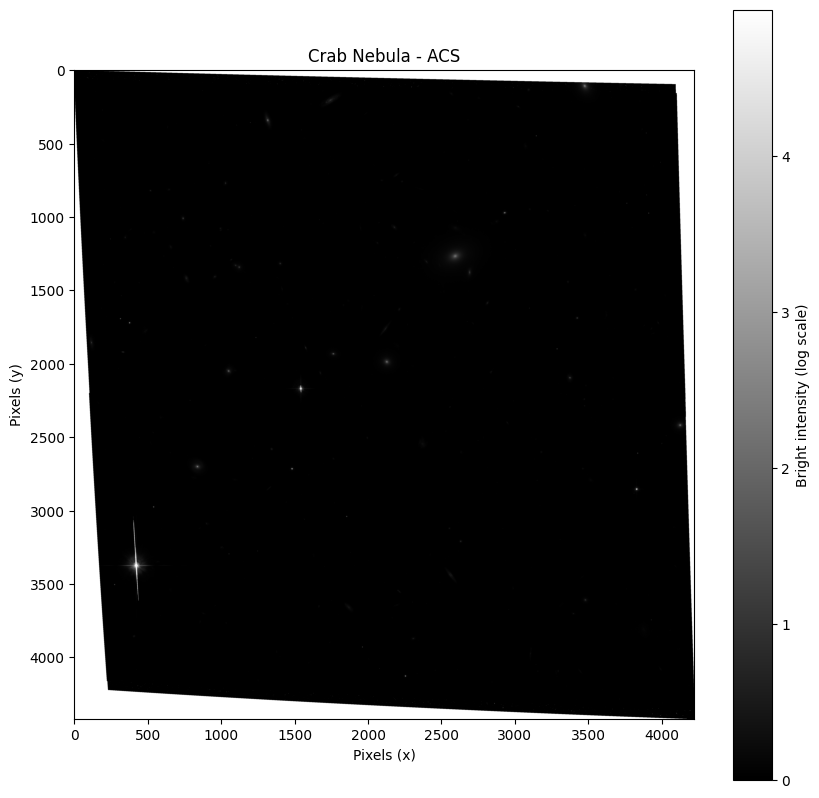

In [4]:
# Visualize image
plt.figure(figsize=(10, 10))
plt.imshow(np.log1p(np.maximum(0, image_data)), cmap=plt.cm.gray)
plt.title(f"Crab Nebula - {header[INSTRUMENT]}")
plt.xlabel("Pixels (x)")
plt.ylabel("Pixels (y)")
plt.colorbar(label="Bright intensity (log scale)")
plt.show()